# Dataset Exploration - DIV2K

Machine Learning Project

Super-Resolution of Retro Game Textures using Deep Learning

Author: Alessio Mele

## Objective

The goal of this notebook is to explore the DIV2K dataset before implementing the training pipeline.

In particular, we aim to:

- inspect the dataset structure;
- analyze image properties;
- verify image dimensions;
- understand how to generate training samples for Super-Resolution.

In [1]:
import sys
from pathlib import Path

# Aggiunge la root del progetto al PYTHONPATH
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from src.utils.image_utils import load_image

## Load the dataset

We instantiate the custom DIV2K dataset implemented in `src/dataset.py`.

In [3]:
from src.dataset import DIV2KDataset
from src.config import DIV2K_TRAIN_DIR

dataset = DIV2KDataset(DIV2K_TRAIN_DIR)

print(len(dataset))

800


In [4]:
from src.utils.image_utils import random_crop
from matplotlib import pyplot as plt

## Visual inspection

We inspect the first image contained in the dataset.

In [5]:
from src.utils.image_utils import random_crop
from matplotlib import pyplot as plt

## Conclusions

The exploration confirmed that:

- the dataset contains 800 training images;
- image resolutions are heterogeneous;
- images are RGB;
- random cropping is necessary before training.

The next step will be generating the corresponding Low-Resolution patches through bicubic downsampling.

In [ ]:
from src.utils.image_utils import bicubic_downsample

In [ ]:
lr_patch, hr_patch = dataset[0]


print(hr_patch.size)
print(lr_patch.size)

(96, 96)
(48, 48)


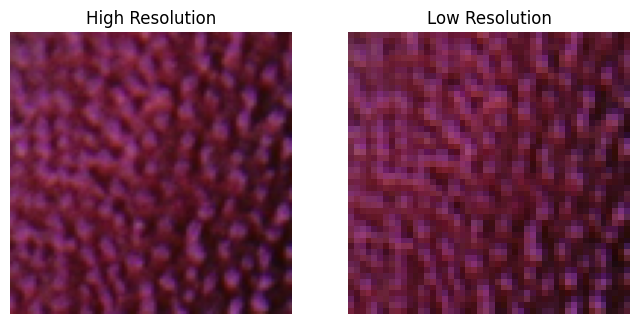

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(hr_patch)
plt.title("High Resolution")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lr_patch)
plt.title("Low Resolution")
plt.axis("off")

plt.show()

In [8]:
lr_patch, hr_patch = dataset[0]

print(type(hr_patch))
print(type(lr_patch))

print(hr_patch.shape)
print(lr_patch.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([3, 96, 96])
torch.Size([3, 48, 48])


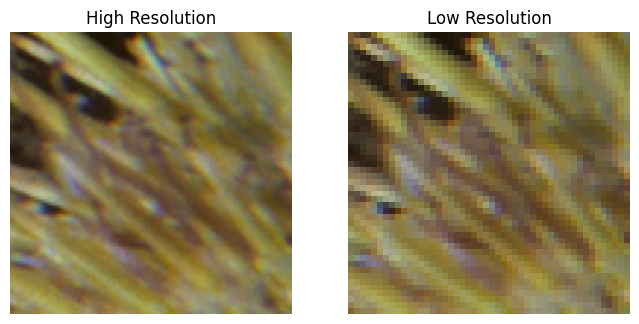

In [9]:
lr_patch, hr_patch = dataset[0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(hr_patch.permute(1,2,0))
plt.title("High Resolution")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lr_patch.permute(1,2,0))
plt.title("Low Resolution")
plt.axis("off")

plt.show()